# Yield Curve Forecasting

Nelson-Siegel baseline fit, RUB–CNY cross-currency spreads, and evaluation.

**Data required:** Run the data pipeline first so the DB has:
- **RU yields:** `cbr_gcurve` and/or `russian_bond_yields`
- **CN yields:** `chinese_bond_yields` (manual ChinaBond files in `src/data_manual/` or pipeline)
- **FRED (optional):** Set `FRED_API_KEY` and run pipeline for `global_indicators` (US rates, oil)

In [34]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.forecasting.loaders import load_russian_yield_curve, load_chinese_yield_curve
try:
    from src.forecasting.loaders import load_global_indicators
except ImportError:
    def load_global_indicators(start_date=None, end_date=None):
        """Fallback: load global_indicators from DB if load_global_indicators not in loaders."""
        try:
            from src.database import DatabaseManager
            from config import DB_PATH
            db = DatabaseManager(str(DB_PATH))
            df = db.load_dataframe("global_indicators")
            if df.empty or "date" not in df.columns:
                return pd.DataFrame()
            df = df.copy()
            df["date"] = pd.to_datetime(df["date"])
            if start_date:
                df = df[df["date"] >= pd.to_datetime(start_date)]
            if end_date:
                df = df[df["date"] <= pd.to_datetime(end_date)]
            return df.set_index("date")
        except Exception:
            return pd.DataFrame()
from src.forecasting.ns_baseline import compute_residuals, get_fitted_curves
import importlib
import src.forecasting.cross_currency as _cc
importlib.reload(_cc)
from src.forecasting.cross_currency import build_spreads, flag_abnormal_spreads
from src.forecasting.evaluate import evaluate_ns_fit, evaluate_spreads
from config import PROJECT_ROOT
import os

FIG_DIR = str(PROJECT_ROOT / "project report" / "graphics")
os.makedirs(FIG_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
print('Setup complete.')

Setup complete.


## 1. Load Yield Curves

In [35]:
# Optional: restrict date range
START_DATE = None  # e.g. '2019-01-01'
END_DATE = None   # e.g. '2025-12-31'

ru_yields = load_russian_yield_curve(start_date=START_DATE, end_date=END_DATE)
cn_yields = load_chinese_yield_curve(start_date=START_DATE, end_date=END_DATE)
glob_ind = load_global_indicators(start_date=START_DATE, end_date=END_DATE)  # FRED: DGS10, oil, etc.
ru_residuals = pd.DataFrame()  # filled by NS fit cell
cn_residuals = pd.DataFrame()

print(f'RU: {len(ru_yields)} rows, {list(ru_yields.columns)}')
print(f'CN: {len(cn_yields)} rows, {list(cn_yields.columns)}')
print(f'FRED (global): {len(glob_ind)} rows, {list(glob_ind.columns) if not glob_ind.empty else []}')

if ru_yields.empty and cn_yields.empty:
    print('No yield data. Run the data pipeline first.')

RU: 219 rows, ['RU_1Y', 'RU_3Y', 'RU_5Y', 'RU_10Y', 'RU_15Y', 'RU_20Y', 'RU_2Y', 'RU_7Y']
CN: 96 rows, ['CN_10Y', 'CN_15Y', 'CN_1Y', 'CN_20Y', 'CN_2Y', 'CN_30Y', 'CN_3M', 'CN_3Y', 'CN_5Y', 'CN_6M', 'CN_7Y', 'CN_9M']
FRED (global): 134 rows, ['DGS10', 'DGS2', 'FEDFUNDS', 'DCOILBRENTEU', 'DTWEXBGS', 'IPMAN', 'UMCSENT']


### 1b. FRED global indicators (US rates, oil)

Optional context: US 10Y (DGS10) and Brent oil for cross-currency interpretation.

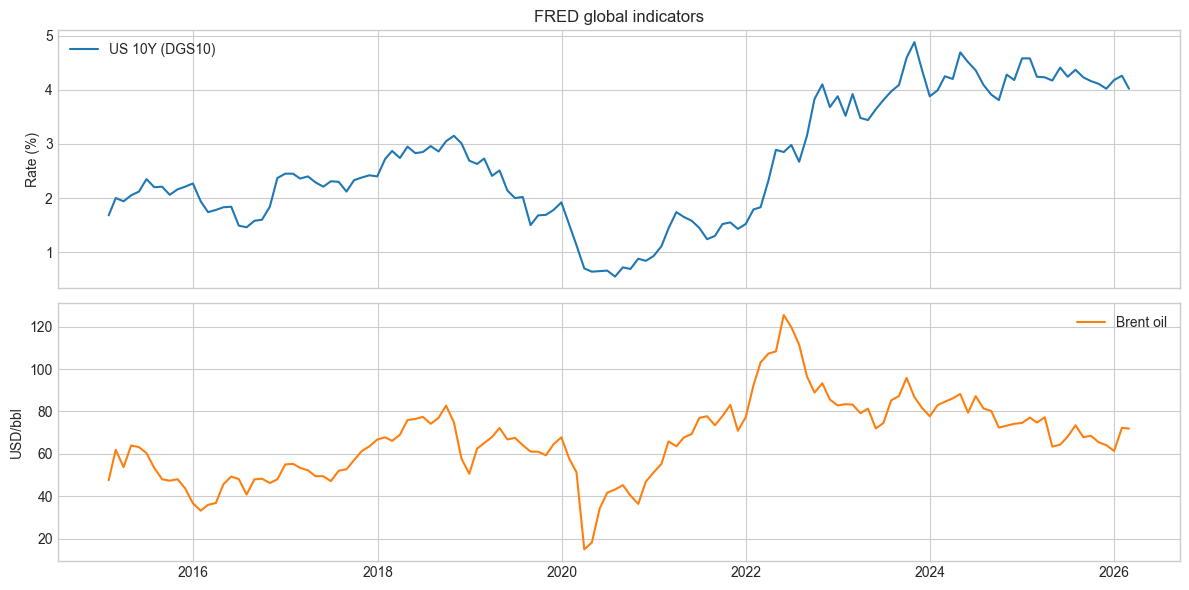

In [36]:
if not glob_ind.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    if 'DGS10' in glob_ind.columns:
        s = glob_ind['DGS10'].dropna()
        if len(s) > 0:
            axes[0].plot(s.index, s.values, label='US 10Y (DGS10)', color='C0')
    if 'DCOILBRENTEU' in glob_ind.columns:
        s = glob_ind['DCOILBRENTEU'].dropna()
        if len(s) > 0:
            axes[1].plot(s.index, s.values, label='Brent oil', color='C1')
    axes[0].set_ylabel('Rate (%)')
    axes[1].set_ylabel('USD/bbl')
    axes[0].legend()
    axes[1].legend()
    axes[0].set_title('FRED global indicators')
    plt.tight_layout()
    plt.show()
else:
    print('No FRED global_indicators in DB. Run pipeline with FRED_API_KEY set.')

## 2. Nelson-Siegel Baseline Fit

In [37]:
if not ru_yields.empty:
    ru_fitted = get_fitted_curves(ru_yields)
    ru_residuals = compute_residuals(ru_yields)
    ru_eval = evaluate_ns_fit(ru_yields, ru_fitted, ru_residuals)
    print('RU Nelson-Siegel:')
    print(f"  MAE mean: {ru_eval.get('overall', {}).get('MAE_mean', 'N/A')}")
    print(f"  RMSE mean: {ru_eval.get('overall', {}).get('RMSE_mean', 'N/A')}")
    display(pd.DataFrame(ru_eval.get('by_maturity', {})).T)
else:
    print('No RU data.')

RU Nelson-Siegel:
  MAE mean: 0.152250628557918
  RMSE mean: 0.23421961145021578


,MAE,RMSE
RU_3Y,0.105230,0.166616
RU_5Y,0.112869,0.156170
RU_10Y,0.334503,0.522644
RU_15Y,0.074333,0.106661
RU_20Y,0.170140,0.277179
RU_2Y,0.052868,0.083960
RU_7Y,0.215811,0.326306


In [38]:
if not cn_yields.empty:
    cn_fitted = get_fitted_curves(cn_yields)
    cn_residuals = compute_residuals(cn_yields)
    cn_eval = evaluate_ns_fit(cn_yields, cn_fitted, cn_residuals)
    print('CN Nelson-Siegel:')
    print(f"  MAE mean: {cn_eval.get('overall', {}).get('MAE_mean', 'N/A')}")
    print(f"  RMSE mean: {cn_eval.get('overall', {}).get('RMSE_mean', 'N/A')}")
    display(pd.DataFrame(cn_eval.get('by_maturity', {})).T)
else:
    print('No CN data.')

CN Nelson-Siegel:
  MAE mean: 0.05103908484097022
  RMSE mean: 0.06436750595871567


,MAE,RMSE
CN_10Y,0.121776,0.137346
CN_15Y,0.022561,0.027088
CN_1Y,0.058774,0.076640
CN_20Y,0.031830,0.042250
CN_2Y,0.057538,0.067918
CN_30Y,0.080428,0.092564
CN_3M,0.071482,0.095476
CN_3Y,0.031122,0.039586
CN_5Y,0.030590,0.039190
CN_6M,0.037919,0.057104


### Comparing Nelson–Siegel accuracy with the literature

To compare your baseline fit with published results:

1. **Use the same metrics**  
   Papers usually report **RMSE** or **MAE** (sometimes both) in **percentage points** (e.g. 0.15% = 15 bp). The notebook already reports MAE and RMSE in the same units as your yields (typically %).

2. **Match sample and maturities**  
   Results depend on the sample period and which maturities are used. Note your date range and maturities (e.g. 2Y–20Y) and compare only to studies that use a similar set and horizon.

3. **Typical ranges (government yield curves)**  
   - **Static NS**: RMSE often in the range **5–30 bp** (0.05–0.30%) per maturity, depending on country and period.  
   - **Dynamic / multi-country**: reported RMSE can be higher (e.g. 10–50 bp).  
   - Build a small table: *Study | Country | Sample | Maturities | RMSE (bp) | MAE (bp)* and add your results (e.g. “This notebook, RU: MAE mean 15.2 bp, RMSE mean 23.4 bp”) for a direct comparison.

In [39]:
# DEBUG: Run this to see why spreads might be empty
from src.forecasting.cross_currency import _common_maturities
common_dates = ru_yields.index.intersection(cn_yields.index)
maturities = _common_maturities(ru_yields.columns.tolist(), cn_yields.columns.tolist())
print(f"Common dates: {len(common_dates)} (sample: {list(common_dates[:3]) if len(common_dates) > 0 else 'none'})")
print(f"Common maturities: {maturities}")
print(f"RU index type: {type(ru_yields.index)}, sample: {ru_yields.index[:2].tolist()}")
print(f"CN index type: {type(cn_yields.index)}, sample: {cn_yields.index[:2].tolist()}")

Common dates: 96 (sample: [Timestamp('2018-01-31 00:00:00'), Timestamp('2018-02-28 00:00:00'), Timestamp('2018-03-31 00:00:00')])
Common maturities: ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y']
RU index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>, sample: [Timestamp('2015-01-31 00:00:00'), Timestamp('2015-02-28 00:00:00')]
CN index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>, sample: [Timestamp('2018-01-31 00:00:00'), Timestamp('2018-02-28 00:00:00')]


## 3. Cross-Currency Spreads (RUB–CNY)

Spread stats:


,mean,std,min,max,count
spread_2Y,8.049224,4.572199,2.390300,19.747186,83.0
spread_3Y,8.437494,4.544191,2.602800,18.834848,73.0
spread_5Y,9.049117,3.907190,2.878724,16.365914,63.0
spread_7Y,9.752896,3.714861,4.016529,17.203048,55.0
spread_10Y,9.488282,3.078165,4.197914,14.018922,55.0
spread_15Y,9.478991,3.530374,3.788954,15.841610,55.0
spread_20Y,11.280753,3.012361,6.575700,16.746171,36.0


Abnormal counts (Z>2):


spread_1Y_abnormal      0
spread_2Y_abnormal     10
spread_3Y_abnormal     11
spread_5Y_abnormal      8
spread_7Y_abnormal      6
spread_10Y_abnormal     5
spread_15Y_abnormal     5
spread_20Y_abnormal     2
dtype: int64

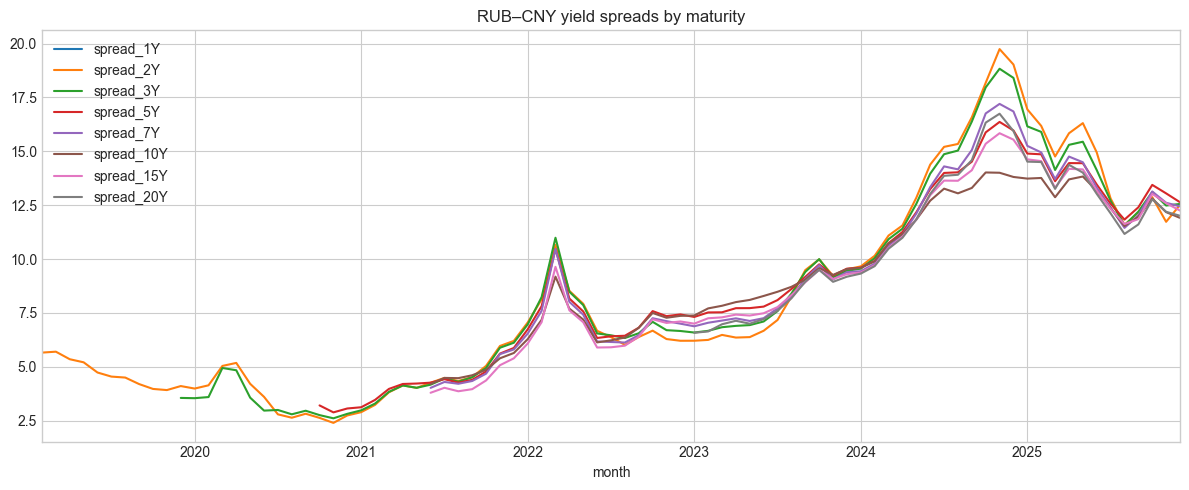

In [40]:
spreads = build_spreads(ru_yields, cn_yields)
if spreads.empty:
    from src.forecasting.cross_currency import _common_maturities
    maturities = _common_maturities(ru_yields.columns.tolist(), cn_yields.columns.tolist())
    print('No spreads. Debug: common_maturities=', maturities)
    print('RU date range:', ru_yields.index.min(), 'to', ru_yields.index.max())
    print('CN date range:', cn_yields.index.min(), 'to', cn_yields.index.max())
else:
    flagged = flag_abnormal_spreads(spreads, z_threshold=2.0)
    spread_eval = evaluate_spreads(spreads, flagged)
    print('Spread stats:')
    display(pd.DataFrame(spread_eval.get('spread_stats', {})).T)
    print('Abnormal counts (Z>2):')
    display(pd.Series(spread_eval.get('abnormal_counts', {})))
    spreads.plot(title='RUB–CNY yield spreads by maturity')
    plt.tight_layout()
    plt.show()

## 4. Residual Plots (RU)

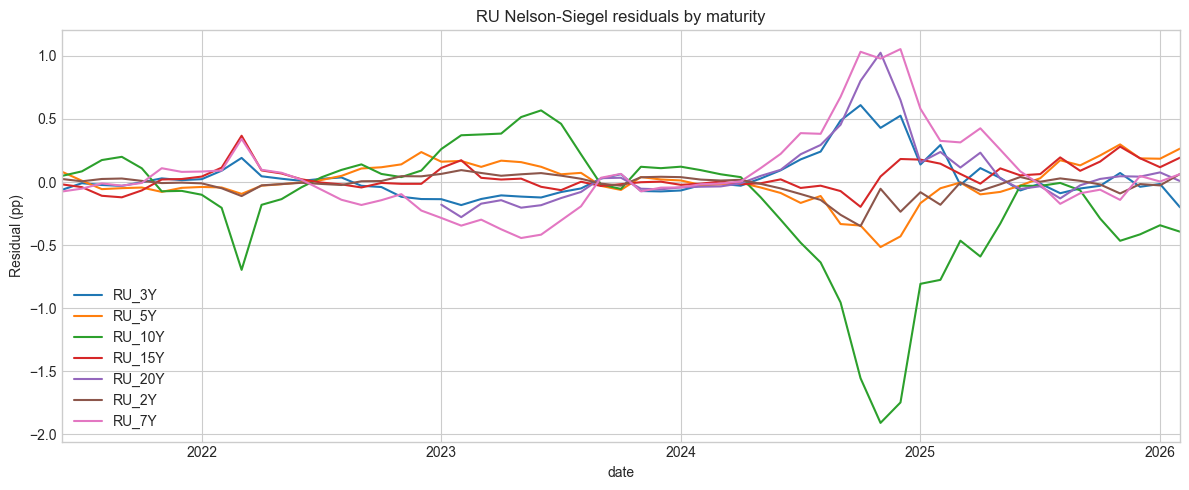

In [41]:
if ru_yields.empty:
    print('No RU yield data. Run the load cell (2) first.')
else:
    if ru_residuals.empty:
        ru_residuals = compute_residuals(ru_yields)
        print('RU residuals computed for plotting (run the "Nelson-Siegel Baseline Fit" cell above for full MAE/RMSE).')
    if not ru_residuals.empty:
        to_plot = ru_residuals.dropna(how='all', axis=1).dropna(how='all')
        if to_plot.empty or to_plot.shape[1] == 0:
            print('No plottable RU residuals (all columns NaN). Ensure NS fit ran successfully.')
        else:
            to_plot.plot(title='RU Nelson-Siegel residuals by maturity', legend=True)
            plt.ylabel('Residual (pp)')
            plt.tight_layout()
            plt.show()
    else:
        print('Could not compute RU residuals (need enough yield columns/maturities).')